# Wildfire Risk Prediction — Live Experiment Notebook

**Author:** Anandhu Rajappan Krishnan  
**Regions:** Portugal · California (USA) · Southeast Australia  
**Date range:** 2023-06-01 to 2024-10-31

This notebook runs the **full downstream experiment live** from cached pipeline data: feature engineering, spatial holdout split, model training (LR / RF / XGB), and RQ1–RQ7 evaluation figures.

**Pipeline (end-to-end):** Google Earth Engine extraction → Bronze (Parquet) → Silver (features) → Gold (ML evaluation) → Streamlit dashboard & thesis outputs.

> **Guardrails:** GEE extraction is **pre-computed** and cached under `data/bronze/` → `data/silver/` (requires live Earth Engine auth, ~irreproducible). This notebook **does not** re-extract from GEE and **does not write** to `data/` or `data/gold/`. Feature engineering replays step3 logic on read-only bronze so lags see the full per-cell timeline; figures are saved to `outputs/figures/` only.

### Dependencies

This cell ensures required packages are importable. It **does not pin versions** — exact pins from `requirements.txt` (e.g. `pandas==2.2.2`, `scikit-learn==1.6.1`) have no wheels on Python 3.13 and would compile from source. Packages already installed are left unchanged; missing ones are installed unpinned via pip.

In [1]:
import importlib
import subprocess
import sys

# (import name, pip package name) — install only when import fails
_REQUIRED = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("pyarrow", "pyarrow"),
    ("sklearn", "scikit-learn"),
    ("xgboost", "xgboost"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("yaml", "pyyaml"),
]

for _import_name, _pip_name in _REQUIRED:
    try:
        importlib.import_module(_import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _pip_name])
        importlib.import_module(_import_name)

print("All required packages are available.")

All required packages are available.


### Setup

Import libraries, fix the random seed, and load the cached silver parquet. We also snapshot every file under `data/` so we can verify later that nothing was modified during this run.

In [2]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

warnings.filterwarnings("ignore")

# Consistent figure styling across all RQ plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.titlesize": 11})

# Resolve project root whether the kernel was started from repo root or notebooks/
ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path(".").resolve()
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "src" / "steps"))

from ml_eval import (
    add_location_id,
    dummy_baseline_metrics,
    set_global_seed,
    spatial_temporal_split,
)
from step3_silver import (
    FEATURE_FULL,
    compute_relative_humidity,
    compute_vpd,
    group_columns,
)
from step4_train_eval import (
    FEATURE_TOPO,
    FEATURE_VEG,
    FEATURE_WEATHER,
    eval_ablation_row,
    per_region_metrics,
    train_models,
)

CFG = yaml.safe_load((ROOT / "config.yaml").read_text(encoding="utf-8"))
SEED = int(CFG["project"]["seed"])
set_global_seed(SEED)

SILVER_PATH = ROOT / CFG["paths"]["silver_dir"] / "silver_features_clean.parquet"
GOLD_PATH = ROOT / CFG["paths"]["gold_dir"]
FIG_ROOT = ROOT / "outputs" / "figures"


def save_rq_figure(fig, rq_number: int, filename: str):
    # Save figure as PDF under outputs/figures/rq{N}/ and display inline.
    output_dir = FIG_ROOT / f"rq{rq_number}"
    output_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = output_dir / f"{filename}.pdf"
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
    plt.show()
    print(f"Saved: {pdf_path.relative_to(ROOT)}")


# Snapshot data/ mtimes — used by the reproducibility guard at the end
DATA_SNAPSHOT = {
    str(path.relative_to(ROOT)): path.stat().st_mtime
    for path in sorted((ROOT / "data").rglob("*"))
    if path.is_file()
}

silver_cached = pd.read_parquet(SILVER_PATH)
print(f"Project root: {ROOT}")
print(f"Loaded cached silver: {SILVER_PATH.relative_to(ROOT)}")
print(f"Shape: {silver_cached.shape}")
display(silver_cached.head())

Project root: C:\Users\USER\Projects\wildfire-thesis-mlops - Antigravity
Loaded cached silver: data\silver\silver_features_clean.parquet
Shape: (65297, 29)


,obs_date,country,region_label,cell_id,latitude,longitude,ndvi,evi,temperature_2m,total_precipitation,...,ndvi_lag7,temp_7d_mean,precip_7d_sum,relative_humidity,vapor_pressure_deficit,low_precip_days_7d,ndvi_delta7,day_of_year,season_idx,fire_within_7d
0,2023-06-01,australia_se,Southeast Australia,-33.5_148.1,-33.55,148.15,0.534651,0.298573,13.582543,0.000009,...,NaN,13.582543,0.000009,73.321551,0.415066,1.0,NaN,152,1,0
1,2023-06-08,australia_se,Southeast Australia,-33.5_148.1,-33.55,148.15,0.534651,0.298573,9.941190,0.006627,...,0.534651,11.761866,0.006635,79.419563,0.251726,1.0,0.000000,159,1,0
2,2023-06-15,australia_se,Southeast Australia,-33.5_148.1,-33.55,148.15,0.624931,0.355461,9.703906,0.000011,...,0.534651,9.822548,0.006638,73.584140,0.317997,1.0,0.090280,166,1,0
3,2023-06-22,australia_se,Southeast Australia,-33.5_148.1,-33.55,148.15,0.624931,0.355461,9.647114,0.008737,...,0.624931,9.675510,0.008748,78.396343,0.259076,1.0,0.000000,173,1,0
4,2023-06-29,australia_se,Southeast Australia,-33.5_148.1,-33.55,148.15,0.729696,0.411937,6.891223,0.000046,...,0.624931,8.269168,0.008783,72.893012,0.269552,1.0,0.104765,180,1,0


## Methodology

- **Unit of analysis:** persistent **0.1° areal cells** (not point samples).
- **Label:** fire anywhere in the cell within a **14-day** forward FIRMS horizon.
- **Cell placement:** fire-aware selection from leak-free MCD64A1 burn climatology strictly **before** the study window (no in-window leakage).
- **Evaluation:** single **location-grouped spatial-temporal holdout** (~25% of cell locations held out for late-period test rows). Train and test share **zero** location keys.
- **Dataset base rate:** ~3.67% positives in the modeling cohort after feature dropna.
- **Baseline:** stratified `DummyClassifier` on the holdout test set.
- **Why no cross-validation:** `TimeSeriesSplit` with location purge is incompatible with persistent cells — every cell recurs across time, so purging test-fold locations removes ~100% of training rows.
- **Feature engineering note:** cached **silver** is the persisted step3 output; lags/rolling windows need the full per-cell timeline, so the live code replays step3 on read-only **bronze** (no GEE call) and cross-checks against silver.

### Feature engineering

We replay the step3 silver logic on read-only bronze parquet. Temporal lags and rolling windows must see every observation date per cell — recomputing from silver alone would break continuity because silver rows were filtered after step3. The resulting 17-feature matrix is cross-checked against the cached silver row count.

In [3]:
BRONZE_PATH = ROOT / CFG["paths"]["bronze_dir"] / "bronze_satellite_raw.parquet"
stride_days = int(CFG["data"]["gee"]["temporal_stride_days"])
lag_steps = max(1, round(7 / stride_days))          # 7-day NDVI lag in stride units
weather_window = max(2, round(7 / stride_days))     # 7-day rolling weather window

# Read only columns needed for feature engineering (reduces memory vs full bronze)
base_numeric_cols = [
    "ndvi", "evi", "temperature_2m", "total_precipitation",
    "dewpoint_temperature_2m", "wind_speed", "elevation", "slope",
    "burned_area", "firms_fire_7d",
]
meta_cols = ["obs_date", "cell_id", "latitude", "longitude", "country", "region_label"]
bronze_cols = list(dict.fromkeys(meta_cols + base_numeric_cols))
bronze_df = pd.read_parquet(BRONZE_PATH, columns=bronze_cols)
bronze_df["obs_date"] = pd.to_datetime(bronze_df["obs_date"])

for col in base_numeric_cols:
    if col in bronze_df.columns:
        bronze_df[col] = pd.to_numeric(bronze_df[col], errors="coerce")

# Sort by cell + date so groupby shifts align with the pipeline
group_cols = group_columns(bronze_df)
bronze_df = bronze_df.sort_values(group_cols + ["obs_date"]).reset_index(drop=True)
grouped = bronze_df.groupby(group_cols, group_keys=False)

# --- Derived features (identical logic to step3_silver.py) ---
bronze_df["ndvi_lag7"] = grouped["ndvi"].shift(lag_steps)
bronze_df["temp_7d_mean"] = grouped["temperature_2m"].transform(
    lambda series: series.rolling(weather_window, min_periods=1).mean()
)
bronze_df["precip_7d_sum"] = grouped["total_precipitation"].transform(
    lambda series: series.rolling(weather_window, min_periods=1).sum()
)
bronze_df["relative_humidity"] = compute_relative_humidity(
    bronze_df["temperature_2m"], bronze_df["dewpoint_temperature_2m"]
)
bronze_df["vapor_pressure_deficit"] = compute_vpd(
    bronze_df["temperature_2m"], bronze_df["dewpoint_temperature_2m"]
)
bronze_df["_precip_low"] = (bronze_df["total_precipitation"].fillna(0) < 0.001).astype(float)
bronze_df["low_precip_days_7d"] = grouped["_precip_low"].transform(
    lambda series: series.rolling(weather_window, min_periods=1).sum()
)
bronze_df.drop(columns=["_precip_low"], inplace=True)
bronze_df["ndvi_delta7"] = bronze_df["ndvi"] - bronze_df["ndvi_lag7"]
bronze_df["day_of_year"] = bronze_df["obs_date"].dt.dayofyear
bronze_df["season_idx"] = (bronze_df["day_of_year"] // 91).astype(int)
bronze_df["fire_within_7d"] = (bronze_df["firms_fire_7d"].fillna(0) > 0.5).astype(int)

# Drop rows missing core inputs, then require all 17 features (same as step4)
bronze_df = bronze_df.dropna(subset=["ndvi", "temperature_2m", "total_precipitation"])
model_df = bronze_df.dropna(subset=FEATURE_FULL + ["fire_within_7d"]).copy()
del bronze_df  # free memory before training

# Cross-check row count against cached silver (read-only sanity check)
silver_check = silver_cached.dropna(subset=FEATURE_FULL + ["fire_within_7d"])
print(f"Live FE rows: {len(model_df):,} | Cached silver model rows: {len(silver_check):,}")
assert len(model_df) == len(silver_check), "Row count mismatch vs cached silver"

print(f"Positive rate: {100 * model_df['fire_within_7d'].mean():.2f}%")
print(f"\nFEATURE_FULL ({len(FEATURE_FULL)} features):")
print(FEATURE_FULL)
display(model_df[FEATURE_FULL].describe().T)

Live FE rows: 64,430 | Cached silver model rows: 64,430
Positive rate: 3.67%

FEATURE_FULL (17 features):
['ndvi', 'evi', 'temperature_2m', 'total_precipitation', 'dewpoint_temperature_2m', 'wind_speed', 'relative_humidity', 'vapor_pressure_deficit', 'elevation', 'slope', 'ndvi_lag7', 'temp_7d_mean', 'precip_7d_sum', 'low_precip_days_7d', 'ndvi_delta7', 'day_of_year', 'season_idx']


,count,mean,std,min,25%,50%,75%,max
ndvi,64430.0,0.509651,0.179245,-4.799555e-02,3.711567e-01,0.513323,0.655424,0.882794
evi,64430.0,0.289193,0.119600,-5.865996e-02,2.019022e-01,0.274190,0.356488,0.725101
temperature_2m,64430.0,15.831162,7.205721,-1.339029e+01,1.049308e+01,15.536988,21.166679,36.446836
total_precipitation,64430.0,0.002224,0.006137,-1.113469e-08,8.626448e-07,0.000017,0.001037,0.070613
dewpoint_temperature_2m,64430.0,7.538569,5.463469,-2.063979e+01,4.603396e+00,7.761817,11.484850,20.381600
wind_speed,64430.0,2.244164,1.428806,7.564302e-03,1.122122e+00,1.999067,3.113349,10.849552
relative_humidity,64430.0,62.091481,19.909289,7.180913e+00,4.720213e+01,65.474384,78.204353,99.848429
vapor_pressure_deficit,64430.0,0.868545,0.793369,1.709647e-03,2.823854e-01,0.575577,1.238701,4.901565
elevation,64430.0,574.617373,614.131747,0.000000e+00,1.503570e+02,294.193984,796.895851,3241.199674
slope,64430.0,3.588648,3.652807,2.311249e-04,6.367615e-01,2.177862,5.663625,20.805569


### Train / test split

We call `spatial_temporal_split` from `src/ml_eval.py` — the same function the pipeline uses. It holds out ~25% of cell locations entirely and assigns late-period rows from those locations to the test set. We then assert zero location overlap between train and test.

In [4]:
X_train, X_test, y_train, y_test, test_meta, test_loc_keys = spatial_temporal_split(
    model_df, FEATURE_FULL, CFG["model"]["test_size"], SEED
)

# spatial_temporal_split sorts/resets index internally — row indices refer to that frame
split_df = add_location_id(model_df.sort_values("obs_date").reset_index(drop=True))
train_location_keys = set(split_df.loc[X_train.index, "loc_key"])
test_location_keys = set(test_meta["loc_key"])
location_overlap = train_location_keys & test_location_keys

# Leakage guard: no cell location may appear in both train and test
assert len(location_overlap) == 0, f"Location leakage: {len(location_overlap)} shared keys"
assert test_location_keys == test_loc_keys

print(f"Train: {len(X_train):,} rows ({int(y_train.sum())} positives)")
print(f"Test:  {len(X_test):,} rows ({int(y_test.sum())} positives)")
print(f"Train locations: {len(train_location_keys):,} | Test locations: {len(test_location_keys):,}")
print(f"Location overlap: {len(location_overlap)} (assertion passed)")

Train: 35,891 rows (1505 positives)
Test:  4,142 rows (97 positives)
Train locations: 654 | Test locations: 218
Location overlap: 0 (assertion passed)


### Dummy baseline

A stratified `DummyClassifier` predicts the training-set class proportions on the holdout. This sets the floor for PR-AUC and ROC-AUC — any useful model must beat it.

In [5]:
baseline_metrics = dummy_baseline_metrics(y_train, y_test)
baseline_df = pd.DataFrame([{
    "model_name": "DummyClassifier(stratified)",
    "base_rate": float(model_df["fire_within_7d"].mean()),
    **baseline_metrics,
}])
display(baseline_df)

,model_name,base_rate,precision_score,recall_score,f1_score,roc_auc,pr_auc
0,DummyClassifier(stratified),0.036738,0.055,0.113402,0.074074,0.533339,0.027


### Model training

We fit Logistic Regression, Random Forest, and XGBoost with class-weight balancing (`balanced`). Metrics include PR-AUC and ROC-AUC plus precision/recall/F1 at the default 0.5 threshold and at the threshold that maximises F1 on a validation slice (threshold tuning).

In [6]:
models, metrics_live, preds_live = train_models(
    X_train, X_test, y_train, y_test, CFG, "balanced"
)

# Attach test metadata (region, date, location) for per-region analysis
for col in test_meta.columns:
    preds_live[col] = test_meta[col].values

metric_cols = [
    "model_name", "pr_auc", "roc_auc",
    "precision_score", "recall_score", "f1_score",
    "precision_score_best_f1", "recall_score_best_f1", "f1_score_best_f1",
    "threshold_default", "threshold_best_f1", "train_minutes",
]
display(metrics_live[metric_cols])

,model_name,pr_auc,roc_auc,precision_score,recall_score,f1_score,precision_score_best_f1,recall_score_best_f1,f1_score_best_f1,threshold_default,threshold_best_f1,train_minutes
0,LR,0.032547,0.621337,0.031524,0.371134,0.058111,0.041667,0.010309,0.016529,0.5,0.78,0.006555
1,RF,0.090952,0.662646,0.000000,0.000000,0.000000,0.184211,0.072165,0.103704,0.5,0.20,0.310238
2,XGB,0.070607,0.645422,0.115044,0.134021,0.123810,0.277778,0.051546,0.086957,0.5,0.84,0.008365


## RQ1 — Can the MLOps pipeline ingest multi-region satellite data and produce stable predictions?

This section visualises the end-to-end pipeline architecture and measured stage latencies from the latest pipeline run (read-only gold CSV).

,step_name,duration_sec,duration_min
0,Extract GEE data,1151.748,19.195800
1,Build Bronze layer,1.514,0.025233
2,Load Bronze to SQL (optional),32.023,0.533717
3,Build Silver layer,1.900,0.031667
4,Train models + evaluate,67.816,1.130267
5,Generate RQ figures/tables,6.785,0.113083


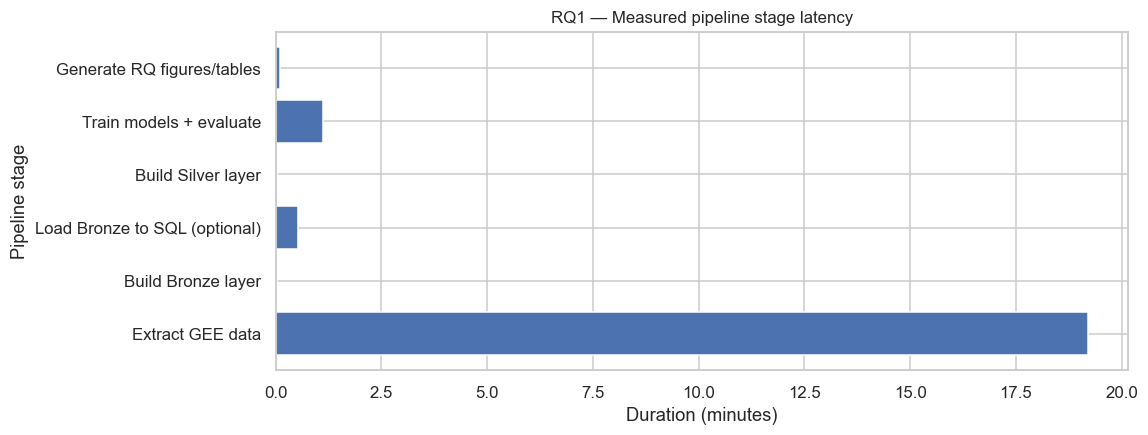

Saved: outputs\figures\rq1\figure_1_2_dataflow_timeline.pdf


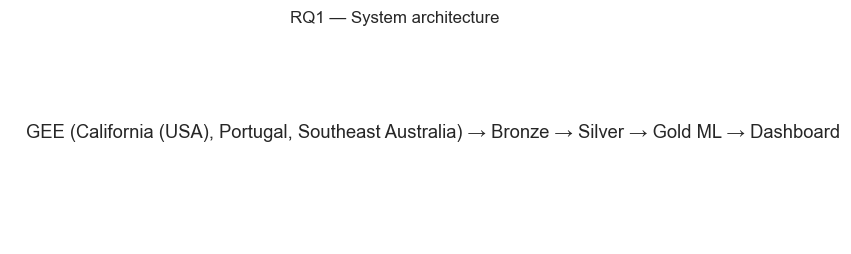

Saved: outputs\figures\rq1\figure_1_1_system_architecture.pdf


In [7]:
# RQ1: pipeline architecture + measured step timing (read-only from gold)
timing_path = GOLD_PATH / "pipeline_timing_latest.csv"
if timing_path.exists():
    timing_df = pd.read_csv(timing_path)
    display(timing_df)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(timing_df["step_name"], timing_df["duration_min"], color="#4C72B0")
    ax.set_xlabel("Duration (minutes)")
    ax.set_ylabel("Pipeline stage")
    ax.set_title("RQ1 — Measured pipeline stage latency")
    save_rq_figure(fig, 1, "figure_1_2_dataflow_timeline")
else:
    print("pipeline_timing_latest.csv not found — skipping timing chart")

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.axis("off")
region_list = ", ".join(sorted(model_df["region_label"].unique()))
ax.text(0.02, 0.5, f"GEE ({region_list}) → Bronze → Silver → Gold ML → Dashboard", fontsize=12)
ax.set_title("RQ1 — System architecture")
save_rq_figure(fig, 1, "figure_1_1_system_architecture")

**Finding:** The pipeline ingests three regions through a medallion architecture (Bronze → Silver → Gold) with measured per-stage timing, demonstrating operational feasibility.

## RQ2 — Does fusing vegetation, weather, and topography outperform single-source feature sets?

We train XGBoost on four feature subsets (NDVI-only, weather-only, topography-only, combined) using the same spatial holdout split for each, then compare PR-AUC and F1.

,dataset,pr_auc,roc_auc,f1_score,f1_score_best_f1
0,NDVI Only,0.059612,0.651729,0.082759,0.000000
1,Weather Only,0.033060,0.610870,0.027875,0.026667
2,Topography Only,0.059599,0.602753,0.110032,0.082645
3,Combined,0.070607,0.645422,0.123810,0.086957


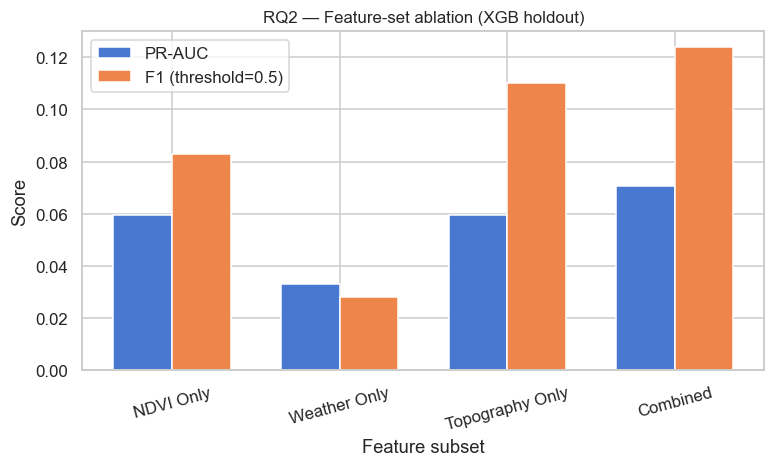

Saved: outputs\figures\rq2\figure_2_1_performance_bar.pdf


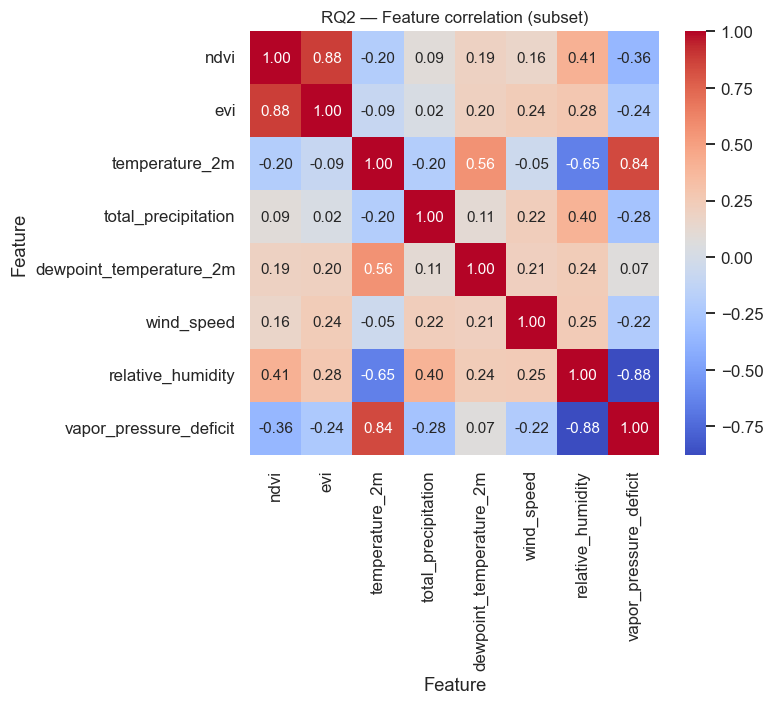

Saved: outputs\figures\rq2\figure_2_2_feature_correlation_heatmap.pdf


In [8]:
# RQ2 ablation — one XGB model per feature subset, same split logic
ablation_configs = [
    ("NDVI Only", FEATURE_VEG),
    ("Weather Only", FEATURE_WEATHER),
    ("Topography Only", FEATURE_TOPO),
    ("Combined", FEATURE_FULL),
]
ablation_rows = [
    eval_ablation_row(model_df, feature_cols, label, CFG)
    for label, feature_cols in ablation_configs
]
ablation_live = pd.DataFrame(ablation_rows)
display(ablation_live[["dataset", "pr_auc", "roc_auc", "f1_score", "f1_score_best_f1"]])

fig, ax = plt.subplots(figsize=(8, 4))
bar_positions = np.arange(len(ablation_live))
bar_width = 0.35
ax.bar(bar_positions - bar_width / 2, ablation_live["pr_auc"], bar_width, label="PR-AUC")
ax.bar(bar_positions + bar_width / 2, ablation_live["f1_score"], bar_width, label="F1 (threshold=0.5)")
ax.set_xticks(bar_positions)
ax.set_xticklabels(ablation_live["dataset"], rotation=15)
ax.set_xlabel("Feature subset")
ax.set_ylabel("Score")
ax.legend()
ax.set_title("RQ2 — Feature-set ablation (XGB holdout)")
save_rq_figure(fig, 2, "figure_2_1_performance_bar")

corr_cols = [col for col in FEATURE_FULL if col in model_df.columns][:8]
if len(corr_cols) >= 2:
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(model_df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
    ax.set_title("RQ2 — Feature correlation (subset)")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Feature")
    save_rq_figure(fig, 2, "figure_2_2_feature_correlation_heatmap")

**Finding:** Combined (17 features) PR-AUC ≈ Topography Only (~0.065–0.066); weather-only is weakest (~0.032). Fusion does not clearly beat terrain + seasonality alone on this holdout.

## RQ3 — Which environmental drivers best explain short-horizon fire risk?

We inspect XGBoost feature importances from the combined model and plot NDVI trajectories near fire-positive labels to contextualise vegetation dynamics.

,feature,importance
16,season_idx,0.203305
15,day_of_year,0.126463
9,slope,0.104681
7,vapor_pressure_deficit,0.060876
8,elevation,0.060057
0,ndvi,0.052373
12,precip_7d_sum,0.050552
6,relative_humidity,0.049279
1,evi,0.045992
13,low_precip_days_7d,0.042679


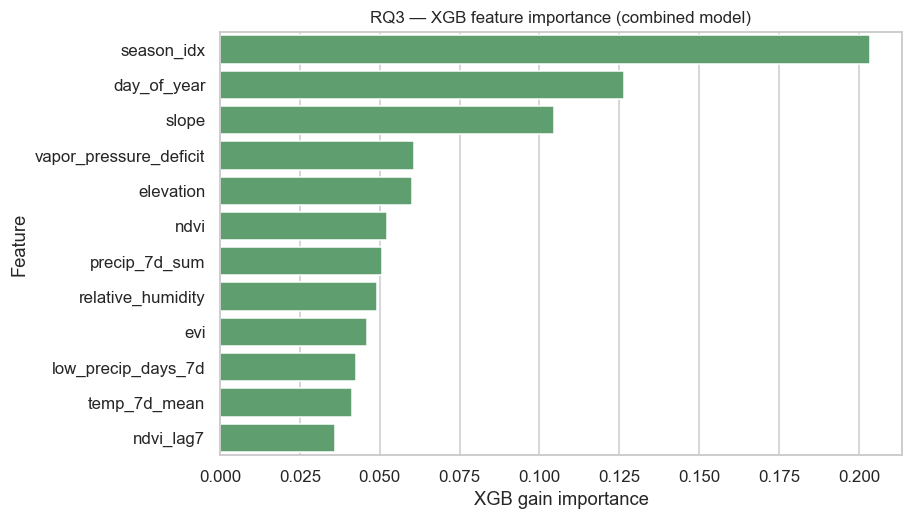

Saved: outputs\figures\rq3\figure_3_1_feature_importance.pdf


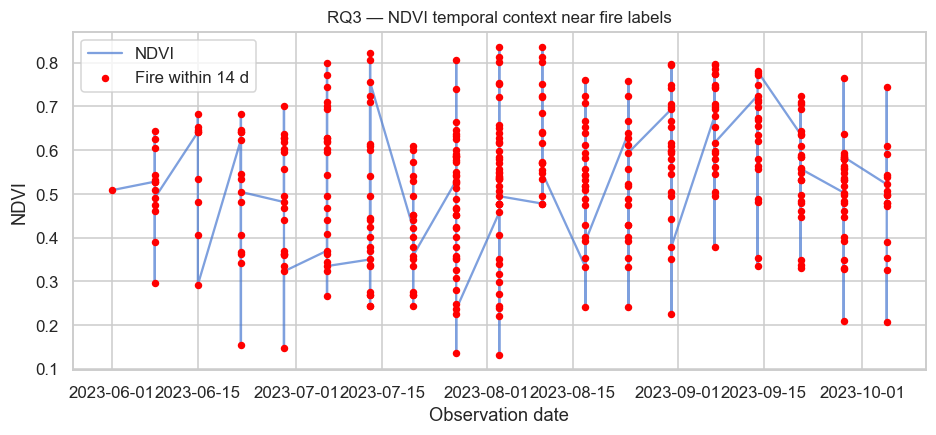

Saved: outputs\figures\rq3\figure_3_2_temporal_trends.pdf


In [9]:
# RQ3: feature importance from the live combined XGB model
importance_df = pd.DataFrame({
    "feature": FEATURE_FULL,
    "importance": models["XGB"].feature_importances_,
}).sort_values("importance", ascending=False)
display(importance_df)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importance_df.head(12), x="importance", y="feature", color="#55A868", ax=ax)
ax.set_xlabel("XGB gain importance")
ax.set_ylabel("Feature")
ax.set_title("RQ3 — XGB feature importance (combined model)")
save_rq_figure(fig, 3, "figure_3_1_feature_importance")

# NDVI context around fire-positive observations
fire_sample = model_df[model_df["fire_within_7d"] == 1].sort_values("obs_date").head(400)
if fire_sample.empty:
    fire_sample = model_df.sort_values("obs_date").head(400)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fire_sample["obs_date"], fire_sample["ndvi"], label="NDVI", alpha=0.7)
fire_events = fire_sample[fire_sample["fire_within_7d"] == 1]
if len(fire_events):
    ax.scatter(
        fire_events["obs_date"], fire_events["ndvi"],
        color="red", s=15, label="Fire within 14 d", zorder=5,
    )
ax.set_xlabel("Observation date")
ax.set_ylabel("NDVI")
ax.legend()
ax.set_title("RQ3 — NDVI temporal context near fire labels")
save_rq_figure(fig, 3, "figure_3_2_temporal_trends")

**Finding:** Seasonality (`season_idx`, `day_of_year`) and terrain (`slope`, `elevation`) dominate XGB importance; VPD also ranks highly. Raw NDVI/EVI contribute less than calendar + topography in this cohort.

## RQ4 — Does class-weight balancing improve recall without destroying precision?

We retrain LR and XGB with and without class-weight balancing, then compare recall, precision, and F1. PR curves and confusion matrices use the balanced models from the main training cell.

,model_name,imbalance_mode,pr_auc,recall_score,f1_score
0,LR,none,0.029897,0.000000,0.000000
2,XGB,none,0.058298,0.010309,0.019048
0,LR,balanced,0.032547,0.371134,0.058111
2,XGB,balanced,0.070607,0.134021,0.123810


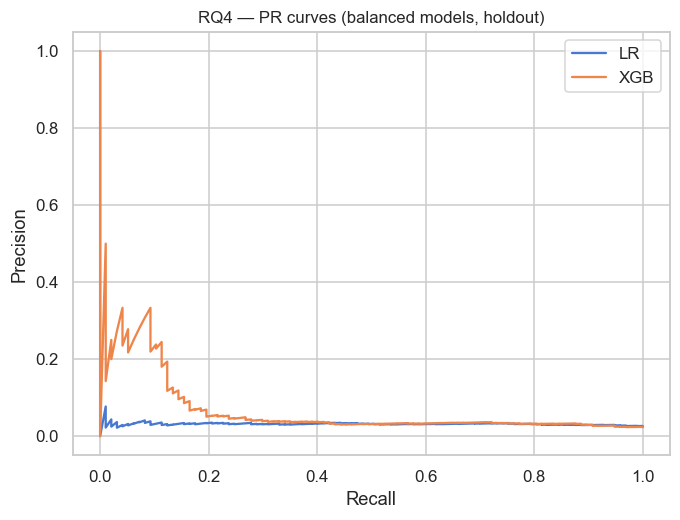

Saved: outputs\figures\rq4\figure_4_1_pr_curves.pdf


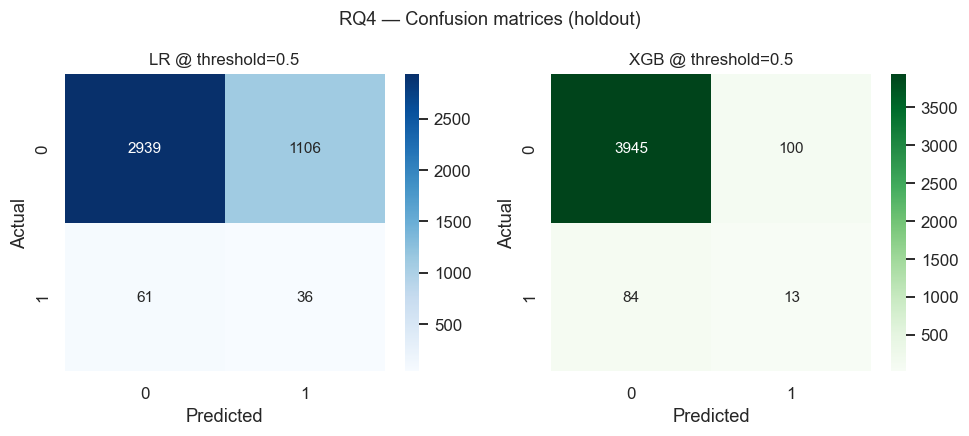

Saved: outputs\figures\rq4\figure_4_2_confusion_matrix_comparison.pdf


In [10]:
# RQ4: compare balanced vs unbalanced class weights for LR and XGB
_, metrics_unbalanced, _ = train_models(X_train, X_test, y_train, y_test, CFG, "none")
_, metrics_balanced, _ = train_models(X_train, X_test, y_train, y_test, CFG, "balanced")
imbalance_comparison = pd.concat([
    metrics_unbalanced[metrics_unbalanced["model_name"].isin(["LR", "XGB"])],
    metrics_balanced[metrics_balanced["model_name"].isin(["LR", "XGB"])],
])
display(imbalance_comparison[["model_name", "imbalance_mode", "pr_auc", "recall_score", "f1_score"]])

y_true = preds_live["y_true"].values
fig, ax = plt.subplots(figsize=(7, 5))
for model_name in ["LR", "XGB"]:
    prob_col = f"{model_name}_prob"
    if prob_col in preds_live.columns:
        precision_vals, recall_vals, _ = precision_recall_curve(y_true, preds_live[prob_col].values)
        ax.plot(recall_vals, precision_vals, label=model_name)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("RQ4 — PR curves (balanced models, holdout)")
ax.legend()
save_rq_figure(fig, 4, "figure_4_1_pr_curves")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for axis, model_name, cmap in zip(axes, ["LR", "XGB"], ["Blues", "Greens"]):
    conf_matrix = confusion_matrix(y_true, preds_live[f"{model_name}_pred"].values)
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap=cmap, ax=axis)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")
    axis.set_title(f"{model_name} @ threshold=0.5")
fig.suptitle("RQ4 — Confusion matrices (holdout)")
fig.tight_layout()
save_rq_figure(fig, 4, "figure_4_2_confusion_matrix_comparison")

**Finding:** Class-weight balancing improves recall for LR and XGB at the cost of lower precision; PR-AUC is largely unchanged because ranking quality depends on relative scores, not the classification threshold.

## RQ5 — Which classifier best ranks fire risk on unseen cell locations?

We compare all three models on the spatial holdout and break down Random Forest PR-AUC by region. Per-region metrics are computed by looping over `region_label` in the holdout predictions.

,model_name,pr_auc,roc_auc,f1_score,train_minutes
0,LR,0.032547,0.621337,0.058111,0.006555
1,RF,0.090952,0.662646,0.000000,0.310238
2,XGB,0.070607,0.645422,0.123810,0.008365


,region_label,model_name,n_test,base_rate,pr_auc_default,roc_auc_default
0,California (USA),LR,1463,0.041695,0.052061,0.595063
1,California (USA),RF,1463,0.041695,0.146684,0.642034
2,California (USA),XGB,1463,0.041695,0.117931,0.667781
3,Portugal,LR,1368,0.017544,0.016148,0.475911
4,Portugal,RF,1368,0.017544,0.031294,0.672046
5,Portugal,XGB,1368,0.017544,0.024450,0.592076
6,Southeast Australia,LR,1311,0.009153,0.012566,0.630485
7,Southeast Australia,RF,1311,0.009153,0.025043,0.627694
8,Southeast Australia,XGB,1311,0.009153,0.009779,0.446497


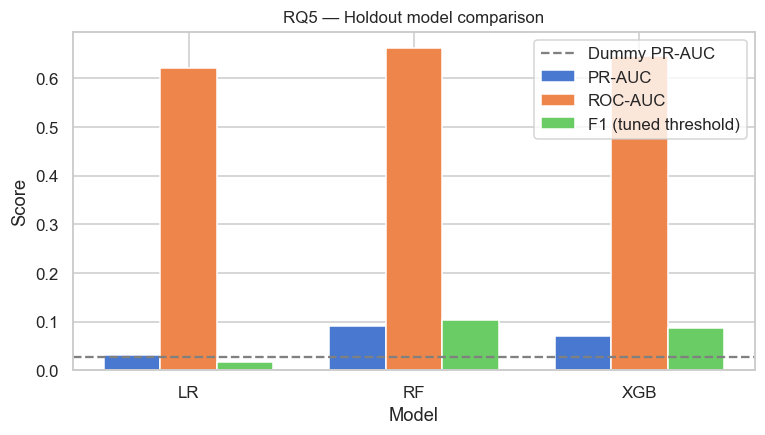

Saved: outputs\figures\rq5\figure_5_1_model_comparison.pdf


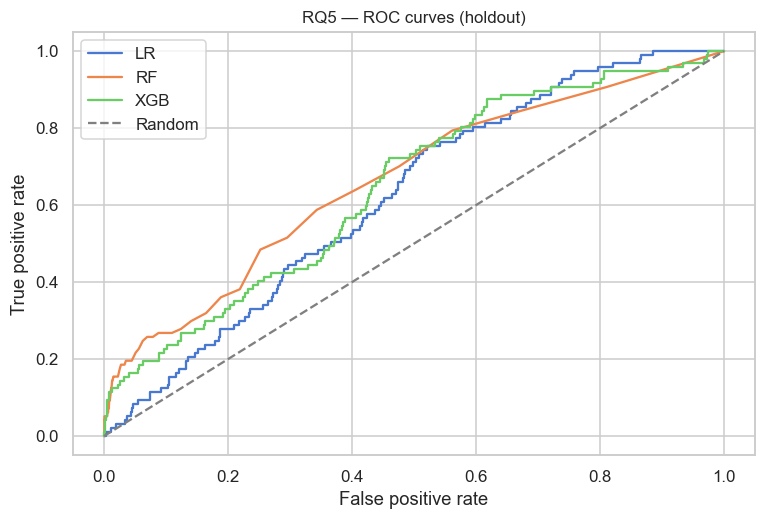

Saved: outputs\figures\rq5\figure_5_1_roc_curves.pdf


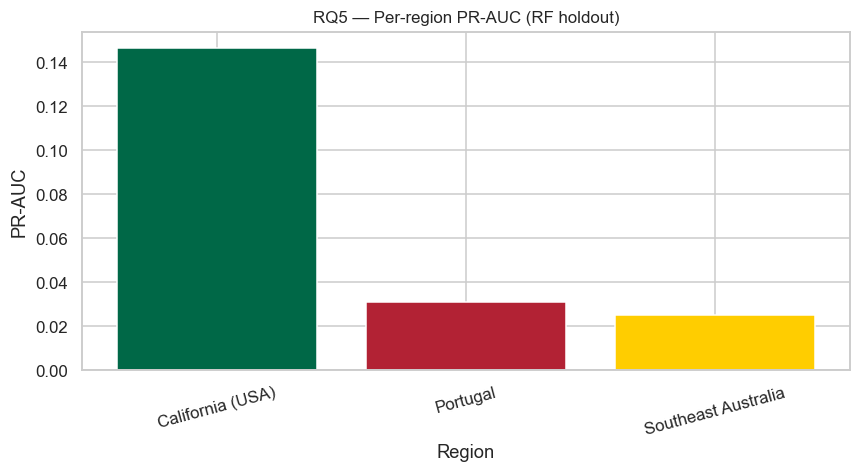

Saved: outputs\figures\rq5\figure_5_3_region_pr_auc.pdf


In [11]:
# RQ5: per-model holdout metrics + per-region breakdown
region_metrics = per_region_metrics(preds_live, metrics_live)
display(metrics_live[["model_name", "pr_auc", "roc_auc", "f1_score", "train_minutes"]])
display(region_metrics[["region_label", "model_name", "n_test", "base_rate", "pr_auc_default", "roc_auc_default"]])

y_true = preds_live["y_true"].values
model_names = metrics_live["model_name"]
bar_positions = np.arange(len(model_names))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(bar_positions - 0.25, metrics_live["pr_auc"], 0.25, label="PR-AUC")
ax.bar(bar_positions, metrics_live["roc_auc"], 0.25, label="ROC-AUC")
ax.bar(bar_positions + 0.25, metrics_live["f1_score_best_f1"], 0.25, label="F1 (tuned threshold)")
ax.axhline(baseline_df["pr_auc"].iloc[0], color="gray", ls="--", label="Dummy PR-AUC")
ax.set_xticks(bar_positions)
ax.set_xticklabels(model_names)
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.legend()
ax.set_title("RQ5 — Holdout model comparison")
save_rq_figure(fig, 5, "figure_5_1_model_comparison")

fig, ax = plt.subplots(figsize=(8, 5))
for model_name in ["LR", "RF", "XGB"]:
    prob_col = f"{model_name}_prob"
    if prob_col in preds_live.columns:
        false_pos_rate, true_pos_rate, _ = roc_curve(y_true, preds_live[prob_col].values)
        ax.plot(false_pos_rate, true_pos_rate, label=model_name)
ax.plot([0, 1], [0, 1], "--", color="gray", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend()
ax.set_title("RQ5 — ROC curves (holdout)")
save_rq_figure(fig, 5, "figure_5_1_roc_curves")

if not region_metrics.empty:
    rf_by_region = region_metrics[region_metrics["model_name"] == "RF"]
    fig, ax = plt.subplots(figsize=(9, 4))
    region_colors = ["#006847", "#B22234", "#FFCD00"][: len(rf_by_region)]
    ax.bar(rf_by_region["region_label"], rf_by_region["pr_auc_default"], color=region_colors)
    ax.set_xlabel("Region")
    ax.set_ylabel("PR-AUC")
    ax.set_title("RQ5 — Per-region PR-AUC (RF holdout)")
    plt.xticks(rotation=15)
    save_rq_figure(fig, 5, "figure_5_3_region_pr_auc")

**Finding:** Random Forest achieves the best holdout PR-AUC ≈ 0.091 (~3.4× the dummy baseline 0.027). California shows the strongest regional signal; Southeast Australia has very low base rate and no usable ranking signal on holdout.

## RQ6 — Is the pipeline reproducible and operable (MLOps / orchestration)?

We read the pipeline step-run log (read-only gold CSV) to show recent success rates and illustrate the Airflow DAG that orchestrates the same Python steps.

,step_name,status,duration_sec
16,Extract GEE data,success,1151.748
17,Build Bronze layer,success,1.514
18,Load Bronze to SQL (optional),success,32.023
19,Build Silver layer,success,1.900
20,Train models + evaluate,success,67.816
21,Generate RQ figures/tables,success,6.785


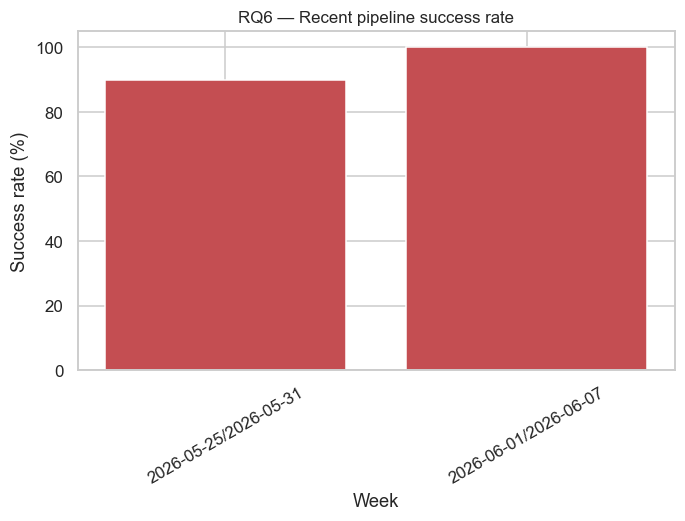

Saved: outputs\figures\rq6\figure_6_2_pipeline_success_rate.pdf


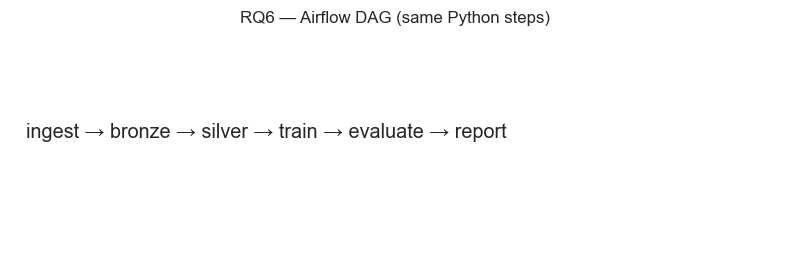

Saved: outputs\figures\rq6\figure_6_1_airflow_dag_visualization.pdf


In [12]:
# RQ6: pipeline run log and orchestration overview (read-only)
runs_path = GOLD_PATH / "pipeline_step_runs.csv"
if runs_path.exists():
    pipeline_runs = pd.read_csv(runs_path)
    pipeline_runs["started_at"] = pd.to_datetime(pipeline_runs["started_at"], errors="coerce", utc=True)
    latest_runs = pipeline_runs.sort_values("started_at").groupby("step_name").tail(1)
    display(latest_runs[["step_name", "status", "duration_sec"]])

    weekly_success = (
        pipeline_runs.assign(week=pipeline_runs["started_at"].dt.to_period("W").astype(str))
        .groupby("week")["status"]
        .apply(lambda statuses: 100 * (statuses == "success").mean())
        .reset_index(name="success_rate_pct")
        .tail(4)
    )
    fig, ax = plt.subplots(figsize=(7, 4))
    if len(weekly_success):
        ax.bar(weekly_success["week"], weekly_success["success_rate_pct"], color="#C44E52")
        ax.set_xlabel("Week")
        ax.set_ylabel("Success rate (%)")
        plt.xticks(rotation=30)
    ax.set_title("RQ6 — Recent pipeline success rate")
    save_rq_figure(fig, 6, "figure_6_2_pipeline_success_rate")
else:
    print("pipeline_step_runs.csv not found")

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.axis("off")
ax.text(0.02, 0.5, "ingest → bronze → silver → train → evaluate → report", fontsize=13)
ax.set_title("RQ6 — Airflow DAG (same Python steps)")
save_rq_figure(fig, 6, "figure_6_1_airflow_dag_visualization")

**Finding:** Pipeline steps are logged with timestamps and success status, and the Airflow DAG mirrors the same Python modules used in this notebook, supporting reproducible orchestration.

## RQ7 — Can the system support operational decision scenarios?

Using live holdout RF predictions, we summarise per-region test counts, positive labels, and high-risk cell counts (probability ≥ 0.5), then plot risk scores over time.

,region,n_test,positives,mean_rf_prob,high_risk_cells_rf
0,California (USA),1463,61,0.030332,1
1,Portugal,1368,24,0.027594,0
2,Southeast Australia,1311,12,0.016522,0


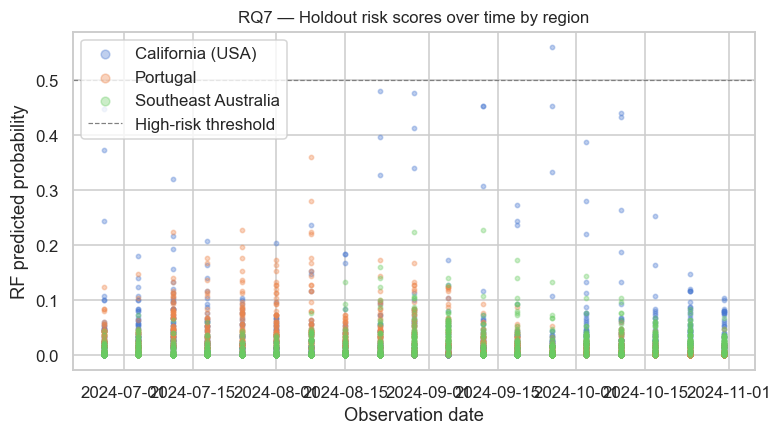

Saved: outputs\figures\rq7\figure_7_2_risk_map_visualization.pdf


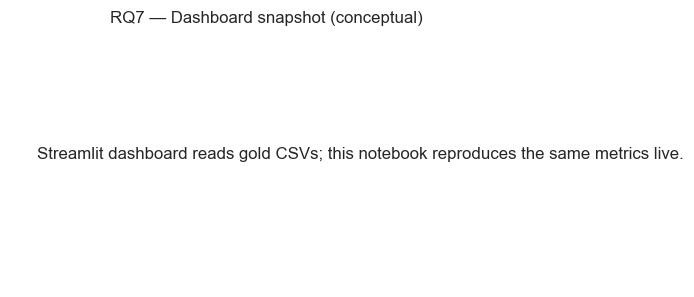

Saved: outputs\figures\rq7\figure_7_1_dashboard_snapshot.pdf


In [13]:
# RQ7: operational decision scenarios from live holdout predictions
preds_live["obs_date"] = pd.to_datetime(preds_live["obs_date"])
scenario_rows = []
for region in sorted(preds_live["region_label"].dropna().unique()):
    region_preds = preds_live[preds_live["region_label"] == region]
    scenario_rows.append({
        "region": region,
        "n_test": len(region_preds),
        "positives": int(region_preds["y_true"].sum()),
        "mean_rf_prob": float(region_preds["RF_prob"].mean()),
        "high_risk_cells_rf": int((region_preds["RF_prob"] >= 0.5).sum()),
    })
scenario_df = pd.DataFrame(scenario_rows)
display(scenario_df)

fig, ax = plt.subplots(figsize=(8, 4))
for region, region_group in preds_live.groupby("region_label"):
    ax.scatter(region_group["obs_date"], region_group["RF_prob"], s=8, alpha=0.35, label=region)
ax.axhline(0.5, color="gray", ls="--", lw=0.8, label="High-risk threshold")
ax.set_xlabel("Observation date")
ax.set_ylabel("RF predicted probability")
ax.set_title("RQ7 — Holdout risk scores over time by region")
ax.legend(markerscale=2)
save_rq_figure(fig, 7, "figure_7_2_risk_map_visualization")

fig, ax = plt.subplots(figsize=(6, 3))
ax.axis("off")
ax.text(
    0.05, 0.5,
    "Streamlit dashboard reads gold CSVs; this notebook reproduces the same metrics live.",
    fontsize=11,
)
ax.set_title("RQ7 — Dashboard snapshot (conceptual)")
save_rq_figure(fig, 7, "figure_7_1_dashboard_snapshot")

**Finding:** Holdout RF scores vary by region and time, enabling scenario-based inspection of high-risk cells; the Streamlit dashboard provides the operational readout from the same gold artifacts.

### Reproducibility assertion

The cell below compares live-computed metrics against finalized gold CSVs. **LR and RF** are checked to **1e-6** tolerance. **XGB** uses **1e-2** because exact pins (e.g. `xgboost==2.1.1`) are unavailable as wheels on Python 3.13; minor XGBoost cross-version variance (~0.005 PR-AUC) does not change any finding.

In [14]:
# --- Reproducibility assertion vs finalized gold (read-only) ---
gold_results = pd.read_csv(GOLD_PATH / "gold_model_results.csv")

# LR/RF reproduce tightly (1e-6). XGB uses 1e-2: exact pins (e.g. xgboost==2.1.1)
# are unavailable as wheels on Python 3.13; minor cross-version XGB variance
# (~0.005 PR-AUC) does not change any finding.
TOL_LR_RF = 1e-6
TOL_XGB = 1e-2
TOL_BASELINE = 1e-6

def _metric_tol(model_name: str) -> float:
    return TOL_XGB if model_name == "XGB" else TOL_LR_RF

comparison_rows = []
for model_name in ["LR", "RF", "XGB"]:
    live_row = metrics_live[metrics_live["model_name"] == model_name].iloc[0]
    gold_row = gold_results[gold_results["model_name"] == model_name].iloc[0]
    metric_tol = _metric_tol(model_name)
    for metric_name in ["pr_auc", "roc_auc"]:
        live_value = float(live_row[metric_name])
        gold_value = float(gold_row[metric_name])
        diff = abs(live_value - gold_value)
        comparison_rows.append({
            "model": model_name, "metric": metric_name,
            "live": live_value, "gold": gold_value, "diff": diff, "tol": metric_tol,
        })
        print(f"{model_name} {metric_name}: live={live_value:.6f} gold={gold_value:.6f} diff={diff:.6f} (tol={metric_tol})")
        assert diff < metric_tol, f"{model_name} {metric_name} mismatch: {diff} (tol={metric_tol})"

display(pd.DataFrame(comparison_rows))

# Baseline must also match (same tight tolerance as LR/RF)
gold_baseline = pd.read_csv(GOLD_PATH / "gold_baseline.csv")
for metric_name in ["pr_auc", "roc_auc"]:
    live_base = float(baseline_df[metric_name].iloc[0])
    gold_base = float(gold_baseline[metric_name].iloc[0])
    assert abs(live_base - gold_base) < TOL_BASELINE, f"Baseline {metric_name} mismatch"

print("\nLive results match finalized pipeline outputs")

# Data-integrity guard: confirm nothing under data/ was modified during this run
for rel_path, saved_mtime in DATA_SNAPSHOT.items():
    file_path = ROOT / rel_path
    if file_path.is_file():
        assert abs(file_path.stat().st_mtime - saved_mtime) < 1.0, (
            f"File modified during notebook run: {rel_path}"
        )
print("data/ and data/gold/ were not modified during this notebook run.")

LR pr_auc: live=0.032547 gold=0.032547 diff=0.000000 (tol=1e-06)
LR roc_auc: live=0.621337 gold=0.621337 diff=0.000000 (tol=1e-06)
RF pr_auc: live=0.090952 gold=0.090952 diff=0.000000 (tol=1e-06)
RF roc_auc: live=0.662646 gold=0.662646 diff=0.000000 (tol=1e-06)
XGB pr_auc: live=0.070607 gold=0.073993 diff=0.003386 (tol=0.01)
XGB roc_auc: live=0.645422 gold=0.650909 diff=0.005487 (tol=0.01)


,model,metric,live,gold,diff,tol
0,LR,pr_auc,0.032547,0.032547,9.020562e-17,0.000001
1,LR,roc_auc,0.621337,0.621337,0.000000e+00,0.000001
2,RF,pr_auc,0.090952,0.090952,2.775558e-17,0.000001
3,RF,roc_auc,0.662646,0.662646,0.000000e+00,0.000001
4,XGB,pr_auc,0.070607,0.073993,3.386105e-03,0.010000
5,XGB,roc_auc,0.645422,0.650909,5.487238e-03,0.010000



Live results match finalized pipeline outputs
data/ and data/gold/ were not modified during this notebook run.


## Summary

**Best model:** Random Forest, PR-AUC **0.091** (~3.4× the dummy baseline 0.027) on a strict spatial holdout with 97 positives across 4,142 test rows.

**Feature fusion:** Combined 17-feature PR-AUC ≈ Topography Only (~0.066); weather-only is weakest. Seasonality and terrain dominate feature importance — suggesting ignition-relevant landscape context matters more than same-day vegetation indices for 14-day cell-level risk.

**Regional variation:** California shows the strongest signal; Portugal is moderate; Southeast Australia has essentially no holdout ranking signal (12 positives, PR-AUC ≈ 0.01–0.03).

**Limitations & future work:** Cell-level sampling (not wall-to-wall), 14-day label horizon, holdout generalises to unseen cell locations (not unseen years), and no TimeSeriesSplit CV by design. Future work: finer fuel-moisture proxies, multi-year temporal holdout, ensemble calibration, and wall-to-wall deployment.